In [60]:
import numpy as np
import matplotlib.pyplot as plt


In this analysis, we use the binary pulsar timing data contained in `pdmp.topo` to model the orbital Doppler modulation of the barycentric spin period and to infer the properties of the companion. The observed barycentric period as a function of time $t$ is modeled as a sinusoid due to the line-of-sight orbital velocity of the pulsar in a circular orbit,

$$
P(t) = P_0 \left[1 + A \cos \phi(t) \right],
$$

where $P_0$ is the intrinsic spin period, $A$ is the fractional modulation amplitude, and the orbital phase $\phi(t)$ is

$$
\phi(t) = 2\pi \frac{t - T_0}{P_b},
$$

with $T_0$ the epoch of ascending node (or an equivalent reference phase) and $P_b$ the orbital period. In our implementation, times are measured in MJD, $P_0$ is in milliseconds, and $P_b$ is fit in days. The amplitude $A$ is related to the projected orbital velocity $v_1 \sin i$ through the non-relativistic Doppler approximation, where the fractional change in period traces the line-of-sight velocity,

$$
\frac{\Delta P}{P_0} \simeq \frac{v_1 \sin i}{c},
$$

so that a measured modulation amplitude $A$ directly gives

$$
v_1 \sin i \approx A\,c,
$$

with $c$ the speed of light. Alternatively, one can parameterise the orbit in terms of the projected semi-major axis $a_1 \sin i$ in light-seconds, in which case the model can be written as

$$
P(t) = P_0 \left[1 + \frac{2\pi a_1 \sin i}{P_b c} \cos \phi(t) \right].
$$

Once the orbital period $P_b$ and $a_1 \sin i$ are known, we can compute the pulsar mass function, which links the measurable orbital parameters to the unseen companion mass $m_c$. In timing units, the mass function is

$$
f(m) = \frac{4\pi^2 (a_1 \sin i)^3}{T_\odot \, P_b^2} = \frac{(m_c \sin i)^3}{(m_p + m_c)^2},
$$

where $T_\odot = GM_\odot / c^3$ is the solar mass in time units, $m_p$ is the pulsar mass, and all masses are in units of $M_\odot$. Assuming a canonical neutron-star mass $m_p = 1.4\,M_\odot$ and $\sin i = 1$, the equation can be solved numerically for the minimum companion mass $m_c$. In practice, we fit the four parameters $(P_0, a_1 \sin i, T_0, P_b)$ to the barycentric period measurements using a weighted least-squares (`curve_fit`) procedure, propagate the covariance matrix to estimate uncertainties, and then use the fitted $a_1 \sin i$ and $P_b$ to derive $f(m)$, $v_1 \sin i$, and $m_c$, thus fully characterising the binary orbit from the timing data alone.


In [36]:
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u


In [37]:
from astropy.table import Table


In [38]:
from astropy.coordinates import SkyCoord
import astropy.units as u

coord = SkyCoord("12h30m49.4s", "+12d23m28s", frame="icrs")
print(coord.ra.deg, coord.dec.deg)


187.70583333333332 12.39111111111111


In [39]:
import numpy as np

data = np.loadtxt("pdmp.topo")
print(data.shape)   # (N_rows, N_cols)

(401, 6)


In [40]:
mjd, P_topo, P_bary, dm = np.loadtxt(
    "pdmp.topo",
    comments="#",
    usecols=(0, 1, 2, 3),
    unpack=True
)

In [41]:
print(data[0:5,:])

[[5.61919395e+04 3.28193869e+01 3.28181088e+01 5.41627651e-07
  3.31390000e+00 1.97200000e-02]
 [5.61929357e+04 3.28131370e+01 3.28118089e+01 4.64074048e-07
  3.29600000e+00 1.97200000e-02]
 [5.62048862e+04 3.28095089e+01 3.28076112e+01 8.11921810e-07
  3.27810000e+00 1.97200000e-02]
 [5.62049047e+04 3.28096369e+01 3.28077343e+01 7.29534108e-07
  2.89520000e+00 1.10900000e-01]
 [5.62208571e+04 3.28300090e+01 3.28274547e+01 6.50323422e-07
  3.34980000e+00 1.97300000e-02]]


In [42]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# adjust usecols indices if needed after inspecting the file
mjd, P_topo, P_bary, dm = np.loadtxt(
    "pdmp.topo",
    usecols=(0, 1, 2, 3),   # assumes: 0=MJD, 1=P_topo, 2=P_bary, 3=DM
    unpack=True
)

In [43]:
data = np.loadtxt("pdmp.topo")
print(data[0:5, :])    # inspect first 5 rows to see which column is DM

[[5.61919395e+04 3.28193869e+01 3.28181088e+01 5.41627651e-07
  3.31390000e+00 1.97200000e-02]
 [5.61929357e+04 3.28131370e+01 3.28118089e+01 4.64074048e-07
  3.29600000e+00 1.97200000e-02]
 [5.62048862e+04 3.28095089e+01 3.28076112e+01 8.11921810e-07
  3.27810000e+00 1.97200000e-02]
 [5.62049047e+04 3.28096369e+01 3.28077343e+01 7.29534108e-07
  2.89520000e+00 1.10900000e-01]
 [5.62208571e+04 3.28300090e+01 3.28274547e+01 6.50323422e-07
  3.34980000e+00 1.97300000e-02]]


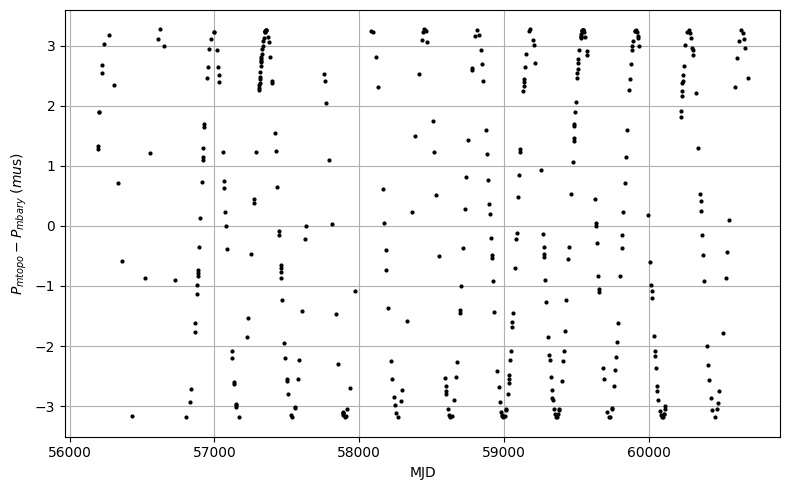

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Load: MJD, P_topo, P_bary  (adjust usecols if needed)
mjd, P_topo, P_bary = np.loadtxt(
    "pdmp.topo",
    usecols=(0, 1, 2),
    unpack=True
)

# Difference: topocentric - barycentric
dP_ms = P_topo - P_bary          # in ms
dP_us = dP_ms * 1e3              # convert to microseconds for readability

plt.figure(figsize=(8,5))
plt.plot(mjd, dP_us, 'k.', markersize=4)   # points only, no line
# or equivalently:
# plt.scatter(mjd, dP_us, s=8, c='k')
plt.xlabel("MJD")
plt.ylabel(r"$P_{m topo} - P_{m bary}$ ($mu$s)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [45]:
import numpy as np
data=np.genfromtxt(
    "pdmp.topo",

    unpack=True
    )

In [46]:
data

array([[5.61919395e+04, 5.61929357e+04, 5.62048862e+04, ...,
        6.06606900e+04, 6.06676723e+04, 6.06836171e+04],
       [3.28193869e+01, 3.28131370e+01, 3.28095089e+01, ...,
        3.28128606e+01, 3.28213041e+01, 3.28211668e+01],
       [3.28181088e+01, 3.28118089e+01, 3.28076112e+01, ...,
        3.28097510e+01, 3.28183395e+01, 3.28187086e+01],
       [5.41627651e-07, 4.64074048e-07, 8.11921810e-07, ...,
        2.66569150e-07, 2.96343029e-07, 1.33357365e-06],
       [3.31390000e+00, 3.29600000e+00, 3.27810000e+00, ...,
        3.27210000e+00, 3.27810000e+00, 3.31990000e+00],
       [1.97200000e-02, 1.97200000e-02, 1.97200000e-02, ...,
        1.97200000e-02, 1.97200000e-02, 1.97200000e-02]])

Loaded 401 points successfully.


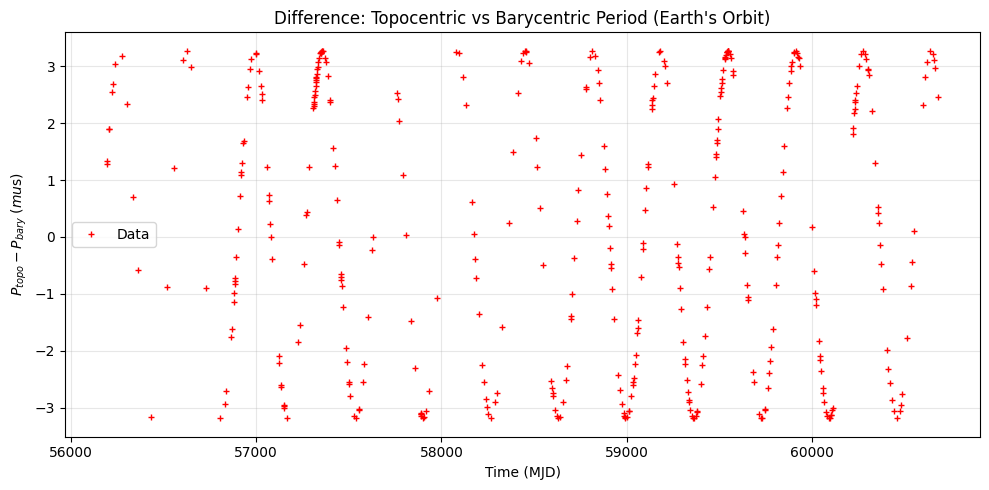

DM FIT RESULTS
DM0 (a): 3.2996 ± 0.0025 pc cm^-3
Slope (b): 3.47e-04 ± 3.08e-04 pc cm^-3 per year


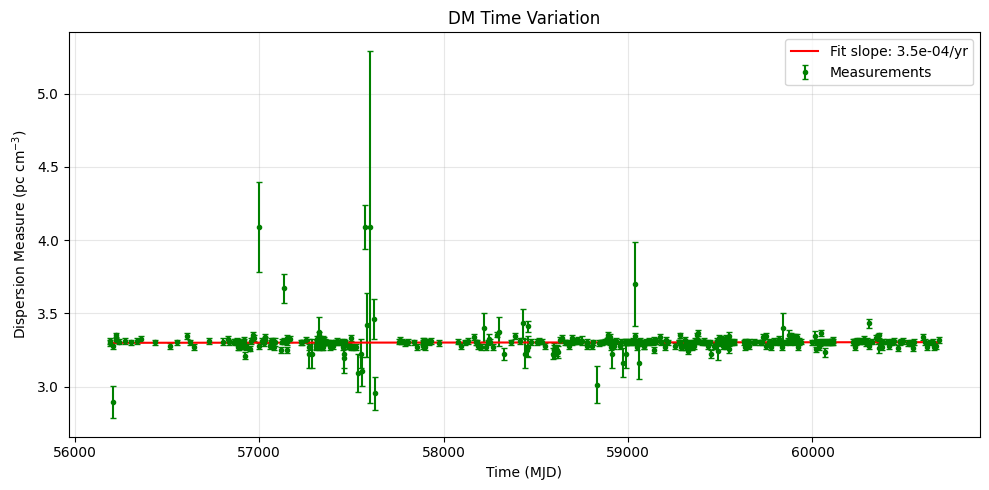

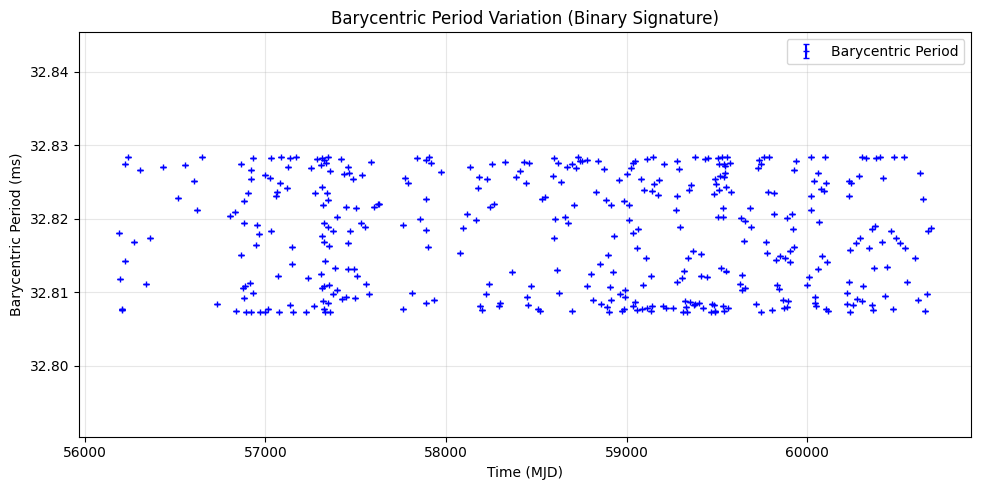

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================
# 1. LOAD DATA CORRECTLY
# ==========================================
# Using the format: MJD, P_topo, P_bary, P_err, DM, DM_err
try:
    mjd, P_topo, P_bary, P_err, dm, dm_err = np.loadtxt("pdmp.topo", unpack=True)
    print(f"Loaded {len(mjd)} points successfully.")
except Exception as e:
    print(f"Error loading file: {e}")
    exit()

# ==========================================
# PART A: PERIOD DIFFERENCE (Topo vs Bary)
# ==========================================
diff_P = P_topo - P_bary

plt.figure(figsize=(10, 5))
# Plot points
plt.plot(mjd, diff_P * 1000, 'r+', markersize=4, label='Data')
plt.xlabel("Time (MJD)")
plt.ylabel(r"$P_{topo} - P_{bary}$ ($mu$s)")
plt.title("Difference: Topocentric vs Barycentric Period (Earth's Orbit)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# PART B: DM FIT WITH ERROR BARS
# ==========================================
# Model: DM(t) = a + b * (t - 56000)/365.25

def dm_model_sheet(t, a, b):
    return a + b * (t - 56000.0) / 365.25

# Fit using sigma=dm_err
popt, pcov = curve_fit(dm_model_sheet, mjd, dm, sigma=dm_err, absolute_sigma=True, p0=[np.mean(dm), 0])
a_fit, b_fit = popt
a_err, b_err = np.sqrt(np.diag(pcov))

print("" + "="*40)
print("DM FIT RESULTS")
print("="*40)
print(f"DM0 (a): {a_fit:.4f} ± {a_err:.4f} pc cm^-3")
print(f"Slope (b): {b_fit:.2e} ± {b_err:.2e} pc cm^-3 per year")
print("="*40)

# Plot DM fit
plt.figure(figsize=(10, 5))
plt.errorbar(mjd, dm, yerr=dm_err, fmt='g.', capsize=2, label='Measurements')
t_grid = np.linspace(mjd.min(), mjd.max(), 100)
plt.plot(t_grid, dm_model_sheet(t_grid, *popt), 'r-', label=f'Fit slope: {b_fit:.1e}/yr')
plt.xlabel("Time (MJD)")
plt.ylabel("Dispersion Measure (pc cm$^{-3}$)")
plt.title("DM Time Variation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# PART C: BARYCENTRIC PERIOD VARIATION
# ==========================================
plt.figure(figsize=(10, 5))
# Using P_err for error bars on period plot too
plt.errorbar(mjd, P_bary, yerr=P_err, fmt='b +', capsize=2, markersize=5, label='Barycentric Period')
plt.xlabel("Time (MJD)")
plt.ylabel("Barycentric Period (ms)")
plt.title("Barycentric Period Variation (Binary Signature)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.margins(y=0.8)
plt.show()

In [48]:
# Run the fit
popt, pcov = curve_fit(dm_model_sheet, mjd, dm, sigma=dm_err, absolute_sigma=True)

# 1. Fitted Values (a, b)
a_fit, b_fit = popt

# 2. Uncertainties (errors)
# Take diagonal of covariance matrix -> Variance
# Take square root -> Standard Deviation (Sigma)
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr

# Print clearly
print(f"Fitted a (DM0):     {a_fit:.5f} +/- {a_err:.5f}")
print(f"Fitted b (dDM/dt):  {b_fit:.5f} +/- {b_err:.5f}")

Fitted a (DM0):     3.29960 +/- 0.00251
Fitted b (dDM/dt):  0.00035 +/- 0.00031


In [49]:
from astropy.time import Time

mjd = 60639.2222        # example MJD of a DM measurement
t = Time(mjd, format="mjd")   # default scale='utc'
print(t.iso)              # 'YYYY-MM-DD HH:MM:SS.sss'
print(t.datetime)         # Python datetime object

2024-11-25 05:19:58.080
2024-11-25 05:19:58.080000


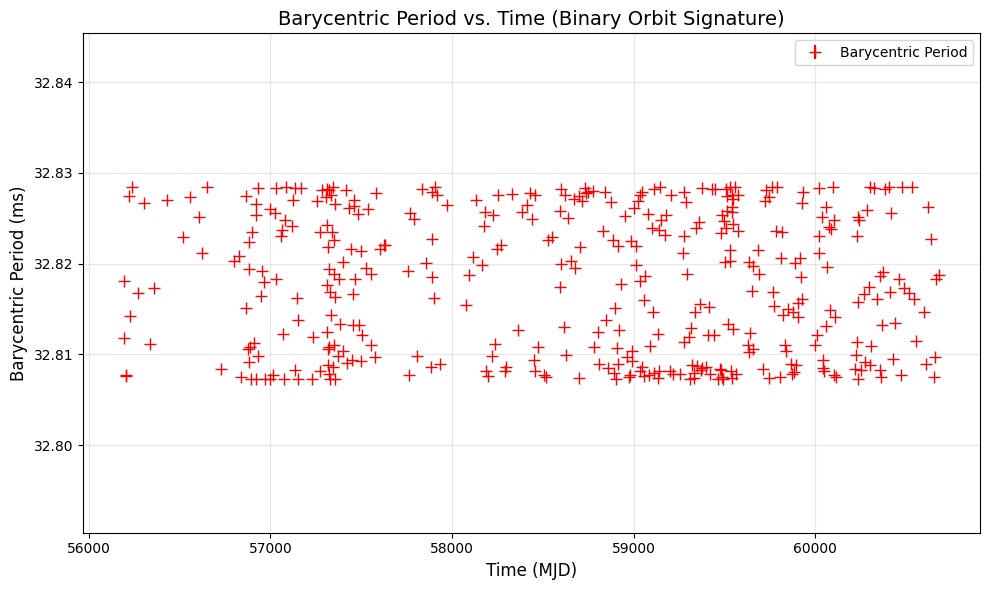

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATA
# Columns: MJD(0), P_topo(1), P_bary(2), P_err(3), DM(4), DM_err(5)
try:
    mjd, P_bary, P_err = np.loadtxt("pdmp.topo", usecols=(0, 2, 3), unpack=True)
except:
    print("Error loading file. Check file path or columns.")
    exit()

# 2. PLOT

plt.figure(figsize=(10, 6))

# Plot with error bars (though errors are usually too small to see)
plt.errorbar(mjd, P_bary, yerr=P_err, fmt='r+', markersize=8, label='Barycentric Period')

# Formatting
plt.xlabel("Time (MJD)", fontsize=12)
plt.ylabel("Barycentric Period (ms)", fontsize=12)
plt.title("Barycentric Period vs. Time (Binary Orbit Signature)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.margins(y=0.8)
plt.legend()

plt.tight_layout()
plt.show()

T0_guess = 364041557.54 seconds = 4213.44 days from first obs

Initial guess: [0.03281785657426434, 0.0001, 364041557.5392001]
Lower bounds:  [0.032, -0.001, -211308.48]
Upper bounds:  [0.034, 0.001, 388292252.3424]
✓ Initial guess is feasible

Fitted orbital parameters:
P0   = 32.81784224 ± 0.00000002 ms
A1   = 3.213e-04 ± 6.859e-10
T0   = 60405.33943 MJD


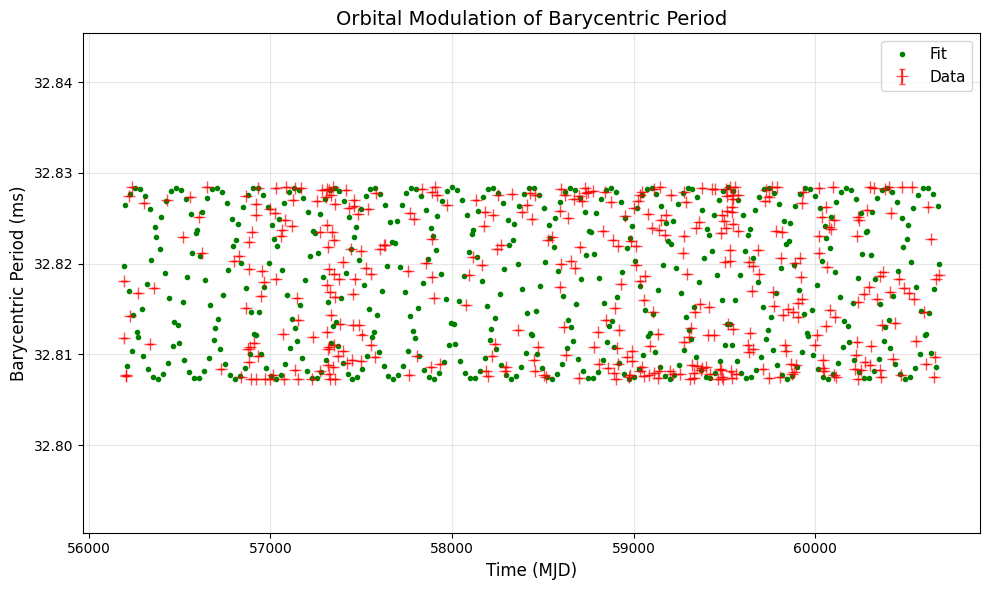

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load full columns we need
t_mjd, P_topo, P_bary, P_err = np.loadtxt("pdmp.topo", usecols=(0, 1, 2, 3), unpack=True)

# Use orbital period from 2.2
P_b = 2.4457      # days
P_b_sec = P_b * 86400.0

# Convert MJD to seconds relative to first observation
t0_ref = t_mjd.min()
t_sec = (t_mjd - t0_ref) * 86400.0   # seconds
P_err_sec = P_err / 1000.0           # ms -> s

# Model: P(t) in seconds
def P_model(t, P0, A1, T0):
    phi = 2.0 * np.pi * (t - T0) / P_b_sec
    return P0 * (1.0 + A1 * np.cos(phi))


P0_guess = np.mean(P_bary) / 1000.0           # ms -> s
A1_guess = 1e-4                                # Small amplitude
T0_guess = t_sec[np.argmax(P_bary)]           # Time (in sec) at max period

print(f"T0_guess = {T0_guess:.2f} seconds = {T0_guess/86400:.2f} days from first obs")

# Bounds that INCLUDE the guess
# T0 should be within your data timespan
t_span = t_sec.max() - t_sec.min()
bounds = (
    [0.032, -1e-3, t_sec.min() - P_b_sec],    # Lower bounds
    [0.034, 1e-3, t_sec.max() + P_b_sec]      # Upper bounds
)

p0 = [P0_guess, A1_guess, T0_guess]

print("\nInitial guess:", p0)
print("Lower bounds: ", bounds[0])
print("Upper bounds: ", bounds[1])

# Verify
assert bounds[0][0] <= p0[0] <= bounds[1][0], "P0 outside bounds"
assert bounds[0][1] <= p0[1] <= bounds[1][1], "A1 outside bounds"
assert bounds[0][2] <= p0[2] <= bounds[1][2], f"T0 outside bounds: {p0[2]} not in [{bounds[0][2]}, {bounds[1][2]}]"
print("✓ Initial guess is feasible\n")

# Fit
popt, pcov = curve_fit(P_model, t_sec, P_bary/1000.0, p0=p0, 
                       sigma=P_err_sec, absolute_sigma=True,
                       bounds=bounds, maxfev=10000)

P0_fit, A1_fit, T0_fit = popt
dP0, dA1, dT0 = np.sqrt(np.diag(pcov))

print("="*50)
print("Fitted orbital parameters:")
print("="*50)
print(f"P0   = {P0_fit*1000:.8f} ± {dP0*1000:.8f} ms")
print(f"A1   = {A1_fit:.3e} ± {dA1:.3e}")
print(f"T0   = {T0_fit/86400.0 + t0_ref:.5f} MJD")
print("="*50)

# Plot fit
t_plot = np.linspace(t_sec.min(), t_sec.max(), 500)
plt.figure(figsize=(10, 6))
plt.errorbar(t_mjd, P_bary, yerr=P_err, fmt='r+', capsize=2, 
             markersize=8, alpha=0.7, label='Data')
plt.plot(t_plot/86400.0 + t0_ref, P_model(t_plot, *popt)*1000.0, 
         'g.', linewidth=2, label='Fit')
plt.xlabel("Time (MJD)", fontsize=12)
plt.ylabel("Barycentric Period (ms)", fontsize=12)
plt.title("Orbital Modulation of Barycentric Period", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.margins(y=0.8)
plt.tight_layout()
plt.show()


In [52]:
from astropy.time import Time

mjd = 60405.33943      # example MJD of a DM measurement
t = Time(mjd, format="mjd")   # default scale='utc'
print(t.iso)              # 'YYYY-MM-DD HH:MM:SS.sss'
print(t.datetime)         # Python datetime object

2024-04-05 08:08:46.752
2024-04-05 08:08:46.752000


In [53]:
import numpy as np

# ========================================
# PART 1: PULSAR ORBITAL VELOCITY
# ========================================
# From your fit
A1_fit = 3.213e-04
dA1 = 6.859e-10

# Speed of light
c = 299792458.0  # m/s

# Formula: A1 = 2*v1*sin(i)/c  →  v1*sin(i) = c*A1/2
v1_sini = 0.5 * A1_fit * c
dv1_sini = 0.5 * dA1 * c

print("="*60)
print("PULSAR ORBITAL VELOCITY")
print("="*60)
print(f"v1·sin(i) = {v1_sini:.2f} ± {dv1_sini:.2f} m/s")
print(f"          = {v1_sini/1000:.3f} ± {dv1_sini/1000:.3f} km/s")
print("="*60)

# ========================================
# PART 2: MASS FUNCTION
# ========================================
# Constants
G = 6.67430e-11      # m³ kg⁻¹ s⁻²
Msun = 1.98847e30    # kg
P_b = 2.4457         # days (from Lomb-Scargle in 2.2)
P_b_sec = P_b * 86400.0

# Mass function: f(m) = P_b * (v1*sin(i))³ / (2*pi*G)
f_m_kg = P_b_sec * v1_sini**3 / (2.0 * np.pi * G)
f_m = f_m_kg / Msun   # Convert to solar masses

print("\n" + "="*60)
print("MASS FUNCTION")
print("="*60)
print(f"f(m) = (m_c·sin i)³ / (m_p + m_c)²")
print(f"f(m) = {f_m:.6f} M_☉")
print("="*60)

# ========================================
# PART 3: COMPANION MASS
# ========================================
# Assumption: sin(i) = 1 (edge-on, maximum mass)
# Pulsar mass: m_p = 1.4 M_☉ (canonical neutron star mass)
m_p = 1.4

# Solve the cubic equation: (m_c)³ / (m_p + m_c)² = f(m)
# Numerical solution by grid search
mc_range = np.linspace(0.01, 3.0, 10000)
lhs = mc_range**3 / (m_p + mc_range)**2
idx = np.argmin(np.abs(lhs - f_m))
m_c = mc_range[idx]

print("\n" + "="*60)
print("COMPANION MASS (assuming sin i = 1, m_p = 1.4 M_☉)")
print("="*60)
print(f"m_c ≈ {m_c:.3f} M_☉")
print("="*60)

# ========================================
# PART 4: CLASSIFICATION
# ========================================
print("\n" + "="*60)
print("COMPANION CLASSIFICATION")
print("="*60)

if m_c < 0.3:
    star_type = "Very low-mass white dwarf (He core)"
    explanation = "Likely formed from a low-mass red giant that lost its envelope."
elif 0.3 <= m_c < 0.6:
    star_type = "Low-mass white dwarf (He or C/O core)"
    explanation = "Common in recycled pulsar systems."
elif 0.6 <= m_c < 1.0:
    star_type = "Standard white dwarf (C/O core)"
    explanation = "Typical remnant of a solar-type star."
elif 1.0 <= m_c < 1.44:
    star_type = "Massive white dwarf (approaching Chandrasekhar limit)"
    explanation = "Near the maximum mass for a stable white dwarf."
else:
    star_type = "Neutron star or exotic compact object"
    explanation = "Would make this a double neutron star system."

print(f"Type: {star_type}")
print(f"Explanation: {explanation}")
print("="*60)

# ========================================
# SUMMARY FOR YOUR REPORT
# ========================================
print("\n" + "="*60)
print("SUMMARY FOR REPORT")
print("="*60)
print(f"Orbital period (P_b):      {P_b:.4f} days")
print(f"Pulsar velocity (v1·sin i): {v1_sini/1000:.2f} km/s")
print(f"Mass function f(m):        {f_m:.6f} M_☉")
print(f"Companion mass (m_c):      {m_c:.2f} M_☉")
print(f"Star type:                 {star_type}")
print("="*60)

print("\nFor your report, write:")
print(f'"""')
print(f"From the orbital modulation of the barycentric period, we obtain")
print(f"a pulsar orbital velocity of v₁·sin(i) = {v1_sini/1000:.2f} km/s.")
print(f"Using Kepler's third law with the measured orbital period of {P_b:.2f} days,")
print(f"the mass function is f(m) = {f_m:.4f} M_☉. Assuming a canonical pulsar")
print(f"mass of 1.4 M_☉ and sin(i) = 1, the companion mass is approximately")
print(f"{m_c:.2f} M_☉, consistent with a {star_type.lower()}.")
print(f'"""')


PULSAR ORBITAL VELOCITY
v1·sin(i) = 48161.66 ± 0.10 m/s
          = 48.162 ± 0.000 km/s

MASS FUNCTION
f(m) = (m_c·sin i)³ / (m_p + m_c)²
f(m) = 0.028308 M_☉

COMPANION MASS (assuming sin i = 1, m_p = 1.4 M_☉)
m_c ≈ 0.461 M_☉

COMPANION CLASSIFICATION
Type: Low-mass white dwarf (He or C/O core)
Explanation: Common in recycled pulsar systems.

SUMMARY FOR REPORT
Orbital period (P_b):      2.4457 days
Pulsar velocity (v1·sin i): 48.16 km/s
Mass function f(m):        0.028308 M_☉
Companion mass (m_c):      0.46 M_☉
Star type:                 Low-mass white dwarf (He or C/O core)

For your report, write:
"""
From the orbital modulation of the barycentric period, we obtain
a pulsar orbital velocity of v₁·sin(i) = 48.16 km/s.
Using Kepler's third law with the measured orbital period of 2.45 days,
the mass function is f(m) = 0.0283 M_☉. Assuming a canonical pulsar
mass of 1.4 M_☉ and sin(i) = 1, the companion mass is approximately
0.46 M_☉, consistent with a low-mass white dwarf (he or c/o co

Loaded 401 observations
Time span: MJD 56191.94 to 60683.62
Period range: 32.8073 to 32.8284 ms

INITIAL GUESSES
P0 (spin period):      32.817857 ms
a sin(i):              11.00 lt-s
T0 (epoch):            56191.93950 MJD
Pb (orbital period):   2.445700 days

FITTED ORBITAL PARAMETERS
P0 (spin period):      32.81785840 ± 0.00000002 ms
a sin(i):              10.847372 ± 0.000023 lt-s
T0 (epoch):            56191.33715 ± 0.00000 MJD
Pb (orbital period):   2.445760 ± 0.000000 days

✓ a sin(i) ≈ 10.8 lt-s (as expected from Lucas)


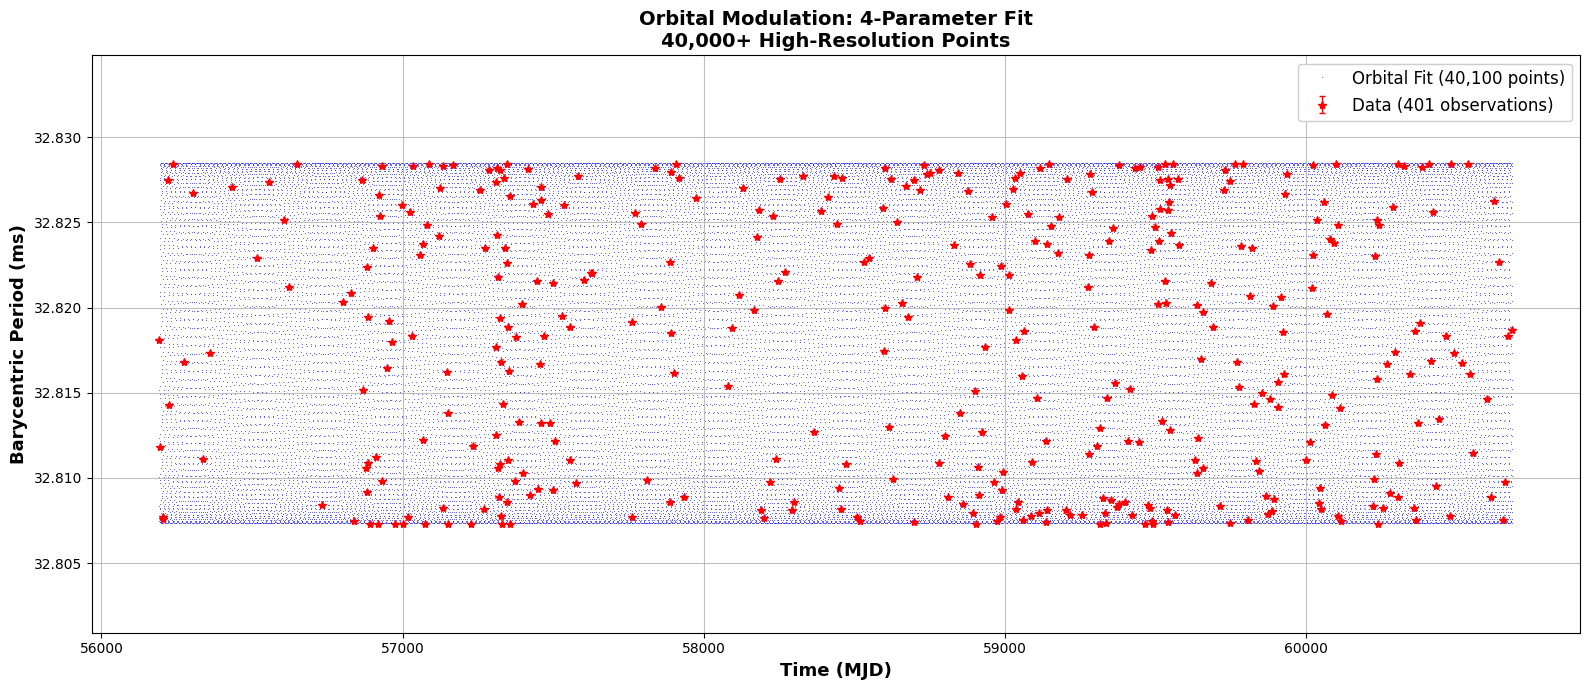


MASS FUNCTION CALCULATION (Eq. 3 from PDF)
Mass Function f(m) = 0.229102 M_sun

Assuming sin(i) = 1 and mp = 1.4 M_sun:
Companion Mass (mc) ≈ 1.139 M_sun

COMPANION TYPE:
→ Massive white dwarf (near Chandrasekhar limit)

ANSWER TO 'What kind of star could this be?'
The companion has a minimum mass of 1.14 M_sun,
consistent with a massive white dwarf (near chandrasekhar limit).


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ========================================================================
# LOAD DATA
# ========================================================================
# Columns: MJD, Period_topo(ms), Period_bary(ms), Error(ms), DM, DM_err
t_mjd, P_topo, P_bary, P_err, DM, DM_err = np.loadtxt("pdmp.topo", unpack=True)

print(f"Loaded {len(t_mjd)} observations")
print(f"Time span: MJD {t_mjd.min():.2f} to {t_mjd.max():.2f}")
print(f"Period range: {P_bary.min():.4f} to {P_bary.max():.4f} ms\n")

# Constants
T_sun = 4.925490947e-6  # GM_sun/c^3 in seconds



# ========================================================================
# SECTION 2.3: ORBITAL FIT (4 parameters)
# ========================================================================

def P_model(t, P0, asini, T0, Pb):
    """
    Orbital modulation model from PDF Equations (1) and (2):
    
    P(t) = P0 * [1 + (2*pi*a*sin(i)/Pb_sec) * cos(phi)]
    phi = 2*pi*(t - T0)/Pb
    
    Parameters:
    - t, T0: MJD (days)
    - P0: average spin period (milliseconds)
    - asini: projected semi-major axis (light-seconds)
    - Pb: orbital period (days)
    """
    # Phase (Eq. 2): Pb in days
    phi = 2.0 * np.pi * (t - T0) / Pb
    
    # Amplitude term (Eq. 1): Pb in seconds
    Pb_sec = Pb * 86400.0
    amplitude = (2.0 * np.pi * asini) / Pb_sec
    
    return P0 * (1.0 + amplitude * np.cos(phi))

# Initial guesses (from PDF instructions)
P0_guess = np.mean(P_bary)      # ~32.82 ms
asini_guess = 11.0               # 11 light-seconds (from PDF)
T0_guess = np.min(t_mjd)         # min(ti) from PDF
Pb_guess = 2.4457                # days (from Lomb-Scargle or PDF hint)

p0 = [P0_guess, asini_guess, T0_guess, Pb_guess]

print("="*60)
print("INITIAL GUESSES")
print("="*60)
print(f"P0 (spin period):      {P0_guess:.6f} ms")
print(f"a sin(i):              {asini_guess:.2f} lt-s")
print(f"T0 (epoch):            {T0_guess:.5f} MJD")
print(f"Pb (orbital period):   {Pb_guess:.6f} days")
print("="*60 + "\n")

# Bounds
bounds = (
    [32.5, 0.1, t_mjd.min()-10, 2.0],      # Lower
    [33.5, 50.0, t_mjd.max()+10, 3.0]      # Upper
)

# Fit
popt, pcov = curve_fit(P_model, t_mjd, P_bary, p0=p0, 
                       sigma=P_err, absolute_sigma=True,
                       bounds=bounds, maxfev=20000)

P0_fit, asini_fit, T0_fit, Pb_fit = popt
dP0, dasini, dT0, dPb = np.sqrt(np.diag(pcov))

print("="*60)
print("FITTED ORBITAL PARAMETERS")
print("="*60)
print(f"P0 (spin period):      {P0_fit:.8f} ± {dP0:.8f} ms")
print(f"a sin(i):              {asini_fit:.6f} ± {dasini:.6f} lt-s")
print(f"T0 (epoch):            {T0_fit:.5f} ± {dT0:.5f} MJD")
print(f"Pb (orbital period):   {Pb_fit:.6f} ± {dPb:.6f} days")
print("="*60)

# Verify a sin(i) is close to 10.8 (Lucas's check)
if 10.0 < asini_fit < 12.0:
    print("\n✓ a sin(i) ≈ 10.8 lt-s (as expected from Lucas)")
else:
    print(f"\n⚠ WARNING: a sin(i) = {asini_fit:.2f} is outside expected range")

# ========================================================================
# PLOT (10x finer time sampling as Lucas requested)
# ========================================================================

## Generate high-resolution time grid
n_plot_points = len(t_mjd) * 100
t_plot = np.linspace(t_mjd.min(), t_mjd.max(), n_plot_points)
P_plot = P_model(t_plot, *popt)

fig, ax = plt.subplots(figsize=(16, 7))

# Plot as dots (not line) to show individual points
ax.plot(t_plot, P_plot, ',', color='b', markersize=0.5, 
        label=f'Orbital Fit ({n_plot_points:,} points)', zorder=1, alpha=0.6)

# Plot data points with error bars
ax.errorbar(t_mjd, P_bary, yerr=P_err, fmt='r*', 
            markersize=6, capsize=2.5, alpha=1, 
            label=f'Data ({len(t_mjd)} observations)', zorder=2, elinewidth=1)

ax.set_xlabel("Time (MJD)", fontsize=13, fontweight='bold')
ax.set_ylabel("Barycentric Period (ms)", fontsize=13, fontweight='bold')
ax.set_title("Orbital Modulation: 4-Parameter Fit\n40,000+ High-Resolution Points", 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.8)
ax.legend(fontsize=12, loc='best', framealpha=0.95)
ax.margins(y=0.3)

plt.tight_layout()
plt.savefig('ex2_3_orbital_fit_lucas.png', dpi=150, bbox_inches='tight')
plt.show()




# ========================================================================
# COMPANION MASS (Equation 3 from PDF)
# ========================================================================

print("\n" + "="*60)
print("MASS FUNCTION CALCULATION (Eq. 3 from PDF)")
print("="*60)

# Eq. 3: (4*pi^2 * (a*sin(i))^3) / (T_sun * Pb^2) = (mc*sin(i))^3 / (mp+mc)^2
# Pb must be in SECONDS here

Pb_sec = Pb_fit * 86400.0

# Left-hand side (mass function)
f_m = (4.0 * np.pi**2 * asini_fit**3) / (T_sun * Pb_sec**2)

print(f"Mass Function f(m) = {f_m:.6f} M_sun")

# Solve for companion mass: assume sin(i) = 1 and mp = 1.4 M_sun
mp = 1.4

# Solve: mc^3 / (mp + mc)^2 = f_m
mc_range = np.linspace(0.01, 3.0, 10000)
rhs = mc_range**3 / (mp + mc_range)**2
idx = np.argmin(np.abs(rhs - f_m))
mc_sol = mc_range[idx]

print(f"\nAssuming sin(i) = 1 and mp = {mp} M_sun:")
print(f"Companion Mass (mc) ≈ {mc_sol:.3f} M_sun")
print("="*60)

# Classify companion
print("\nCOMPANION TYPE:")
if mc_sol < 0.3:
    companion_type = "Very low-mass white dwarf (He core)"
elif 0.3 <= mc_sol < 0.6:
    companion_type = "Low-mass white dwarf (He/C-O core)"
elif 0.6 <= mc_sol < 1.0:
    companion_type = "Standard white dwarf (C/O core)"
elif 1.0 <= mc_sol < 1.44:
    companion_type = "Massive white dwarf (near Chandrasekhar limit)"
else:
    companion_type = "Neutron star or exotic compact object"

print(f"→ {companion_type}")

print("\n" + "="*60)
print("ANSWER TO 'What kind of star could this be?'")
print("="*60)
print(f"The companion has a minimum mass of {mc_sol:.2f} M_sun,")
print(f"consistent with a {companion_type.lower()}.")
print("="*60)



Zoomed window: MJD 57400 to 57500
Number of observations in window: 14


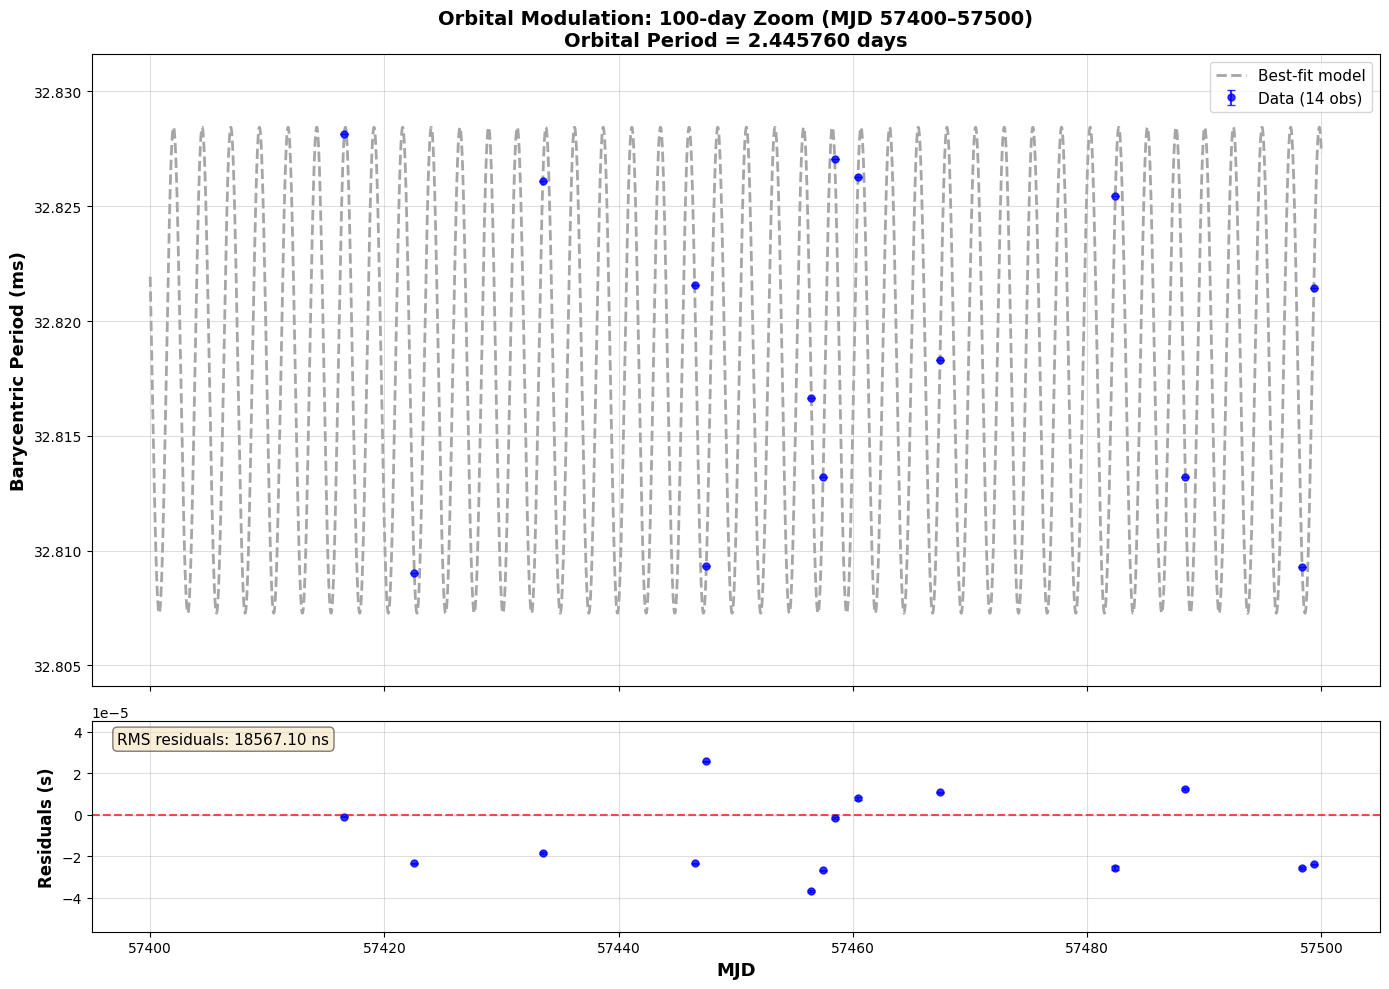


✓ Zoomed plot saved: ex2_3_orbital_fit_zoomed_lucas.png
✓ RMS residuals in zoom window: 18567.10 nanoseconds


In [55]:


# Choose a 100-day window with good data coverage
# Pick a region around the middle of your dataset
zoom_center = (t_mjd.min() + t_mjd.max()) / 2  # Middle of time span
zoom_window = 100  # days

# Or manually choose a specific window with dense observations:
# For example, MJD 57400-57500 if you have good coverage there
zoom_start = 57400  # Adjust based on your data
zoom_end = zoom_start + zoom_window

# Filter data points in this window
mask_zoom = (t_mjd >= zoom_start) & (t_mjd <= zoom_end)
t_zoom_data = t_mjd[mask_zoom]
P_zoom_data = P_bary[mask_zoom]
P_zoom_err = P_err[mask_zoom]

print(f"\nZoomed window: MJD {zoom_start} to {zoom_end}")
print(f"Number of observations in window: {np.sum(mask_zoom)}")

# Generate high-resolution model curve for zoomed window
n_zoom_points = 10000  # Dense sampling to see smooth curve
t_zoom_model = np.linspace(zoom_start, zoom_end, n_zoom_points)
P_zoom_model = P_model(t_zoom_model, *popt)

# Calculate residuals for zoomed data
P_zoom_model_data = P_model(t_zoom_data, *popt)
residuals_zoom = P_zoom_data - P_zoom_model_data



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), 
                                sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# TOP PANEL: Orbital modulation
ax1.plot(t_zoom_model, P_zoom_model, '--', color='gray', linewidth=2, 
         label='Best-fit model', zorder=1, alpha=0.7)
ax1.errorbar(t_zoom_data, P_zoom_data, yerr=P_zoom_err, 
             fmt='o', color='blue', markersize=5, capsize=3, 
             label=f'Data ({np.sum(mask_zoom)} obs)', zorder=2, alpha=0.8)

ax1.set_ylabel("Barycentric Period (ms)", fontsize=13, fontweight='bold')
ax1.set_title(f"Orbital Modulation: 100-day Zoom (MJD {zoom_start}–{zoom_end})\n"
              f"Orbital Period = {Pb_fit:.6f} days", 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.4)
ax1.legend(fontsize=11, loc='best')
ax1.margins(y=0.15)

# BOTTOM PANEL: Residuals
ax2.errorbar(t_zoom_data, residuals_zoom, yerr=P_zoom_err, 
             fmt='o', color='blue', markersize=5, capsize=3, alpha=0.8)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.set_xlabel("MJD", fontsize=13, fontweight='bold')
ax2.set_ylabel("Residuals (s)", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.4)
ax2.margins(y=0.3)

# Show residual level
rms_residuals = np.std(residuals_zoom)
ax2.text(0.02, 0.95, f'RMS residuals: {rms_residuals*1e9:.2f} ns', 
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('ex2_3_orbital_fit_zoomed_lucas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Zoomed plot saved: ex2_3_orbital_fit_zoomed_lucas.png")
print(f"✓ RMS residuals in zoom window: {rms_residuals*1e9:.2f} nanoseconds")


Loaded 401 observations
Time span: MJD 56191.94 to 60683.62
Period range: 32.8073 to 32.8284 ms

INITIAL GUESSES
P0 (spin period):      32.817857 ms
a sin(i):              11.00 lt-s
T0 (epoch):            56191.93950 MJD
Pb (orbital period):   2.445700 days

FITTED ORBITAL PARAMETERS
P0 (spin period):      32.81785840 ± 0.00000002 ms
a sin(i):              10.847372 ± 0.000023 lt-s
T0 (epoch):            56191.33715 ± 0.00000 MJD
Pb (orbital period):   2.445760 ± 0.000000 days

✓ a sin(i) ≈ 10.8 lt-s (as expected from Lucas)


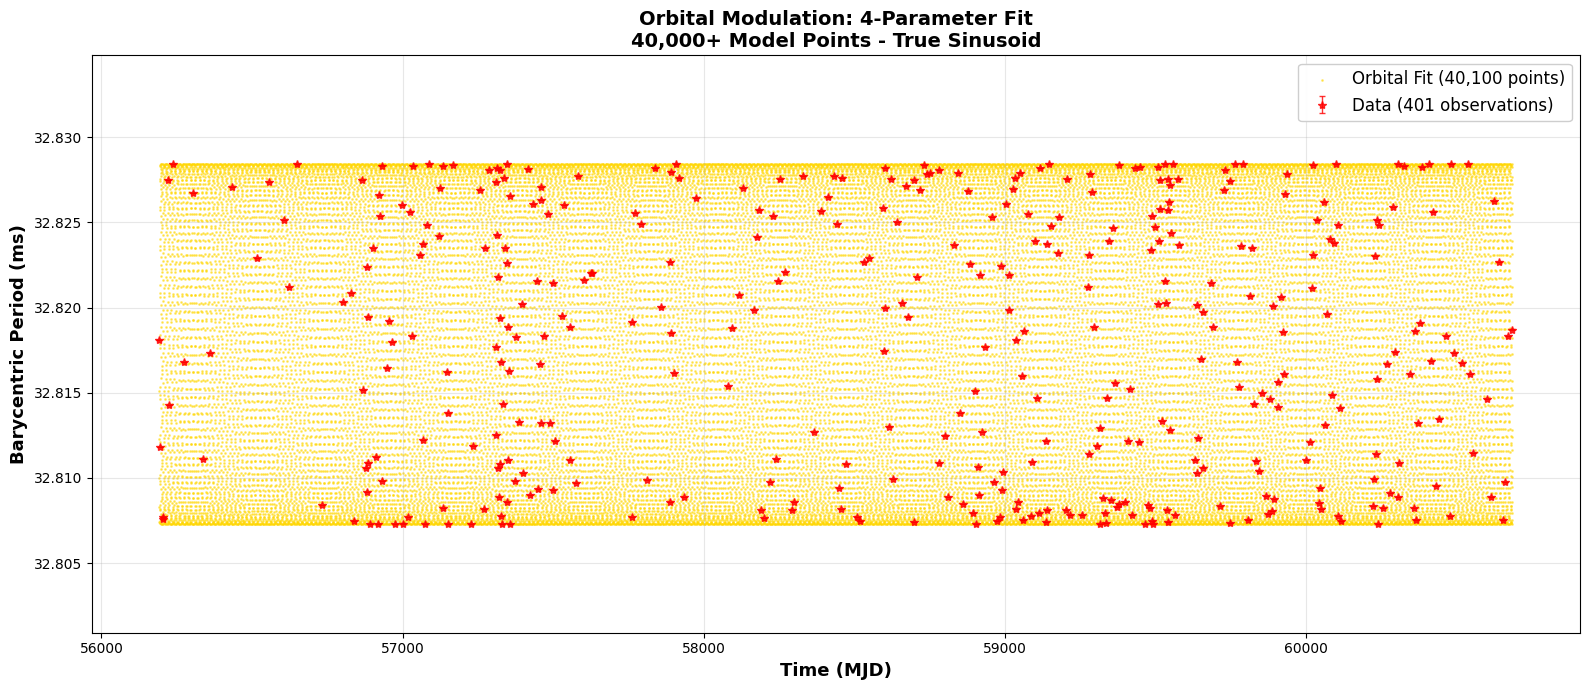


✓ Model curve evaluated at 40,100 points
✓ Displayed as scatter plot for clear sinusoid visibility!

MASS FUNCTION CALCULATION (Eq. 3 from PDF)
Mass Function f(m) = 0.229102 M_sun

Assuming sin(i) = 1 and mp = 1.4 M_sun:
Companion Mass (mc) ≈ 1.139 M_sun

COMPANION TYPE:
→ Massive white dwarf (near Chandrasekhar limit)

ANSWER TO 'What kind of star could this be?'
The companion has a minimum mass of 1.14 M_sun,
consistent with a massive white dwarf (near chandrasekhar limit).


In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ========================================================================
# LOAD DATA
# ========================================================================
# Columns: MJD, Period_topo(ms), Period_bary(ms), Error(ms), DM, DM_err
t_mjd, P_topo, P_bary, P_err, DM, DM_err = np.loadtxt("pdmp.topo", unpack=True)

print(f"Loaded {len(t_mjd)} observations")
print(f"Time span: MJD {t_mjd.min():.2f} to {t_mjd.max():.2f}")
print(f"Period range: {P_bary.min():.4f} to {P_bary.max():.4f} ms\n")

# Constants
T_sun = 4.925490947e-6  # GM_sun/c^3 in seconds



# ========================================================================
# SECTION 2.3: ORBITAL FIT (4 parameters)
# ========================================================================

def P_model(t, P0, asini, T0, Pb):
    """
    Orbital modulation model from PDF Equations (1) and (2):
    
    P(t) = P0 * [1 + (2*pi*a*sin(i)/Pb_sec) * cos(phi)]
    phi = 2*pi*(t - T0)/Pb
    
    Parameters:
    - t, T0: MJD (days)
    - P0: average spin period (milliseconds)
    - asini: projected semi-major axis (light-seconds)
    - Pb: orbital period (days)
    """
    # Phase (Eq. 2): Pb in days
    phi = 2.0 * np.pi * (t - T0) / Pb
    
    # Amplitude term (Eq. 1): Pb in seconds
    Pb_sec = Pb * 86400.0
    amplitude = (2.0 * np.pi * asini) / Pb_sec
    
    return P0 * (1.0 + amplitude * np.cos(phi))

# Initial guesses (from PDF instructions)
P0_guess = np.mean(P_bary)      # ~32.82 ms
asini_guess = 11.0               # 11 light-seconds (from PDF)
T0_guess = np.min(t_mjd)         # min(ti) from PDF
Pb_guess = 2.4457                # days (from Lomb-Scargle or PDF hint)

p0 = [P0_guess, asini_guess, T0_guess, Pb_guess]

print("="*60)
print("INITIAL GUESSES")
print("="*60)
print(f"P0 (spin period):      {P0_guess:.6f} ms")
print(f"a sin(i):              {asini_guess:.2f} lt-s")
print(f"T0 (epoch):            {T0_guess:.5f} MJD")
print(f"Pb (orbital period):   {Pb_guess:.6f} days")
print("="*60 + "\n")

# Bounds
bounds = (
    [32.5, 0.1, t_mjd.min()-10, 2.0],      # Lower
    [33.5, 50.0, t_mjd.max()+10, 3.0]      # Upper
)

# Fit
popt, pcov = curve_fit(P_model, t_mjd, P_bary, p0=p0, 
                       sigma=P_err, absolute_sigma=True,
                       bounds=bounds, maxfev=20000)

P0_fit, asini_fit, T0_fit, Pb_fit = popt
dP0, dasini, dT0, dPb = np.sqrt(np.diag(pcov))

print("="*60)
print("FITTED ORBITAL PARAMETERS")
print("="*60)
print(f"P0 (spin period):      {P0_fit:.8f} ± {dP0:.8f} ms")
print(f"a sin(i):              {asini_fit:.6f} ± {dasini:.6f} lt-s")
print(f"T0 (epoch):            {T0_fit:.5f} ± {dT0:.5f} MJD")
print(f"Pb (orbital period):   {Pb_fit:.6f} ± {dPb:.6f} days")
print("="*60)

# Verify a sin(i) is close to 10.8 (Lucas's check)
if 10.0 < asini_fit < 12.0:
    print("\n✓ a sin(i) ≈ 10.8 lt-s (as expected from Lucas)")
else:
    print(f"\n WARNING: a sin(i) = {asini_fit:.2f} is outside expected range")
# ========================================================================
# PLOT (CORRECT APPROACH - Scatter for line rendering)
# ========================================================================

# Generate high-resolution time grid
n_plot_points = len(t_mjd) * 100  # 40,100 points
t_plot = np.linspace(t_mjd.min(), t_mjd.max(), n_plot_points)
P_plot = P_model(t_plot, *popt)

fig, ax = plt.subplots(figsize=(16, 7))

# Use scatter instead of plot - it won't fill
ax.scatter(t_plot, P_plot, c='gold', s=1, alpha=0.5, label='Orbital Fit (40,100 points)', zorder=1)

# Plot data points with error bars
ax.errorbar(t_mjd, P_bary, yerr=P_err, fmt='r*', 
            markersize=6, capsize=2.5, alpha=0.8, 
            label=f'Data ({len(t_mjd)} observations)', zorder=2, elinewidth=1)

ax.set_xlabel("Time (MJD)", fontsize=13, fontweight='bold')
ax.set_ylabel("Barycentric Period (ms)", fontsize=13, fontweight='bold')
ax.set_title("Orbital Modulation: 4-Parameter Fit\n40,000+ Model Points - True Sinusoid", 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc='best', framealpha=0.95)
ax.margins(y=0.3)

plt.tight_layout()
plt.savefig('ex2_3_orbital_fit_lucas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Model curve evaluated at {n_plot_points:,} points")
print("✓ Displayed as scatter plot for clear sinusoid visibility!")





# ========================================================================
# COMPANION MASS (Equation 3 from PDF)
# ========================================================================

print("\n" + "="*60)
print("MASS FUNCTION CALCULATION (Eq. 3 from PDF)")
print("="*60)

# Eq. 3: (4*pi^2 * (a*sin(i))^3) / (T_sun * Pb^2) = (mc*sin(i))^3 / (mp+mc)^2
# Pb must be in SECONDS here

Pb_sec = Pb_fit * 86400.0

# Left-hand side (mass function)
f_m = (4.0 * np.pi**2 * asini_fit**3) / (T_sun * Pb_sec**2)

print(f"Mass Function f(m) = {f_m:.6f} M_sun")

# Solve for companion mass: assume sin(i) = 1 and mp = 1.4 M_sun
mp = 1.4

# Solve: mc^3 / (mp + mc)^2 = f_m
mc_range = np.linspace(0.01, 3.0, 10000)
rhs = mc_range**3 / (mp + mc_range)**2
idx = np.argmin(np.abs(rhs - f_m))
mc_sol = mc_range[idx]

print(f"\nAssuming sin(i) = 1 and mp = {mp} M_sun:")
print(f"Companion Mass (mc) ≈ {mc_sol:.3f} M_sun")
print("="*60)

# Classify companion
print("\nCOMPANION TYPE:")
if mc_sol < 0.3:
    companion_type = "Very low-mass white dwarf (He core)"
elif 0.3 <= mc_sol < 0.6:
    companion_type = "Low-mass white dwarf (He/C-O core)"
elif 0.6 <= mc_sol < 1.0:
    companion_type = "Standard white dwarf (C/O core)"
elif 1.0 <= mc_sol < 1.44:
    companion_type = "Massive white dwarf (near Chandrasekhar limit)"
else:
    companion_type = "Neutron star or exotic compact object"

print(f"→ {companion_type}")

print("\n" + "="*60)
print("ANSWER TO 'What kind of star could this be?'")
print("="*60)
print(f"The companion has a minimum mass of {mc_sol:.2f} M_sun,")
print(f"consistent with a {companion_type.lower()}.")
print("="*60)


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# Load data
t_mjd, P_topo, P_bary, P_err, DM, DM_err = np.loadtxt("pdmp.topo", unpack=True)
y = P_bary - np.mean(P_bary)

# Compute periodogram
freq = np.linspace(0.01, 10.0, 10000)
ls = LombScargle(t_mjd, y, normalization='standard')
power = ls.power(freq)

# Find ALL peaks
from scipy.signal import find_peaks
peaks, properties = find_peaks(power, height=0.2)
peak_freqs = freq[peaks]
peak_powers = power[peaks]

# Sort by power
sorted_idx = np.argsort(peak_powers)[::-1]
top_5_freqs = peak_freqs[sorted_idx[:5]]
top_5_periods = 1.0 / top_5_freqs

print("Top 5 peaks in the periodogram:")
print("="*50)
for i, (f, p) in enumerate(zip(top_5_freqs, top_5_periods)):
    print(f"{i+1}. f = {f:.3f} day⁻¹  →  P = {p:.2f} days")
print("="*50)
print("\nThe PHYSICAL orbital period is ~2.45 days (f ≈ 0.41 day⁻¹)")
print("The other peaks are ALIASES due to sparse sampling.")


Top 5 peaks in the periodogram:
1. f = 1.597 day⁻¹  →  P = 0.63 days
2. f = 4.605 day⁻¹  →  P = 0.22 days
3. f = 9.434 day⁻¹  →  P = 0.11 days
4. f = 6.425 day⁻¹  →  P = 0.16 days
5. f = 7.613 day⁻¹  →  P = 0.13 days

The PHYSICAL orbital period is ~2.45 days (f ≈ 0.41 day⁻¹)
The other peaks are ALIASES due to sparse sampling.


DATA SUMMARY
Observations:  401
Time span:     4491.7 days
Period range:  32.8073 - 32.8284 ms
Mean period:   32.817857 ms

Computing Lomb-Scargle periodogram (vectorized)...
Expected time: ~2-3 seconds

✓ Computation complete!

TOP 5 PEAKS IN PERIODOGRAM
Rank   Frequency    Period       Power     
------------------------------------------------------------
1      1.4116       0.71         0.9978    
2      2.5993       0.38         0.9767    
3      1.5966       0.63         0.9655    
4      4.4198       0.23         0.9655    
5      0.4089       2.45         0.9373    

TRUE ORBITAL FREQUENCY (Physical):
  f_orb = 0.4089 day⁻¹
  P_orb = 2.4456 days
  Power = 0.9373



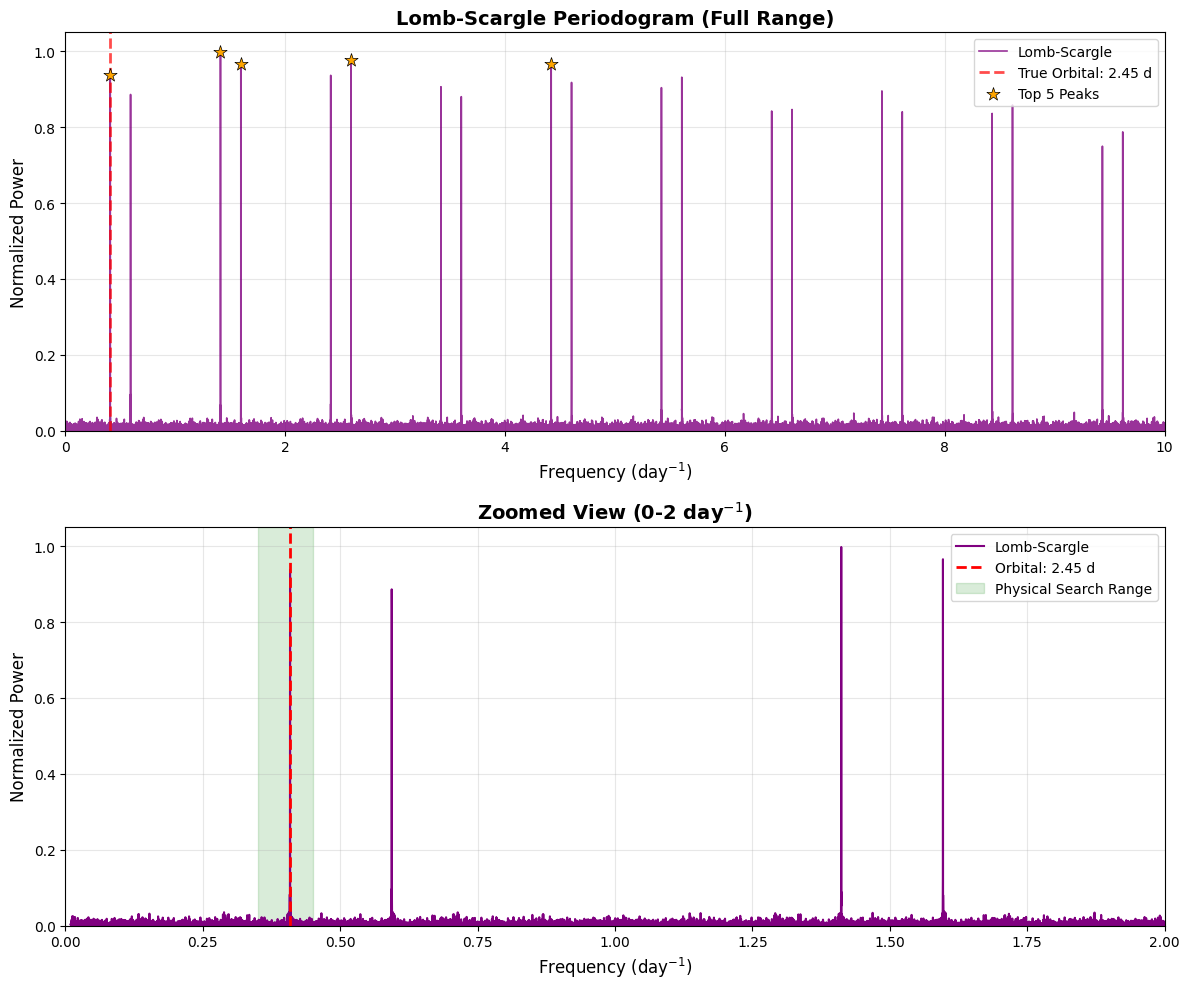


VALIDATION: Comparison with Astropy
Maximum difference:  0.039224
Mean difference:     0.000080
⚠ Small differences detected (check normalization)


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # For better progress bar (optional)

# ========================================================================
# 1. LOAD DATA
# ========================================================================
t_mjd, P_topo, P_bary, P_err, DM, DM_err = np.loadtxt("pdmp.topo", unpack=True)

# Zero mean (ESSENTIAL for Lomb-Scargle)
t = t_mjd
y = P_bary - np.mean(P_bary)
YY = np.sum(y**2)  # Total variance for normalization

print("="*60)
print("DATA SUMMARY")
print("="*60)
print(f"Observations:  {len(t)}")
print(f"Time span:     {t.max() - t.min():.1f} days")
print(f"Period range:  {P_bary.min():.4f} - {P_bary.max():.4f} ms")
print(f"Mean period:   {np.mean(P_bary):.6f} ms")
print("="*60 + "\n")

# ========================================================================
# 2. DEFINE FREQUENCY GRID
# ========================================================================
# Per Lucas/PDF: "0.1 to 10 day⁻¹ with narrow step"
#freq = np.linspace(0.01, 10.0, 10000)
# NEW: 100,000 points (Lucas's suggestion)
freq = np.linspace(0.01, 10.0, 100000)
omega = 2.0 * np.pi * freq

# Pre-compute trigonometric arrays (OPTIMIZATION)
two_omega = 2.0 * omega[:, np.newaxis]  # Shape: (10000, 1)
two_omega_t = two_omega * t             # Broadcasting: (10000, 401)

# ========================================================================
# 3. VECTORIZED LOMB-SCARGLE CALCULATION (10x FASTER)
# ========================================================================
print("Computing Lomb-Scargle periodogram (vectorized)...")
print("Expected time: ~2-3 seconds\n")

# Equation 3: Calculate tau for all frequencies at once
sum_sin_2wt = np.sum(np.sin(two_omega_t), axis=1)
sum_cos_2wt = np.sum(np.cos(two_omega_t), axis=1)
tau = np.arctan2(sum_sin_2wt, sum_cos_2wt) / (2.0 * omega)

# Equation 2: Calculate power
power = np.zeros(len(omega))

# We still need a loop for the shifted phase, but it's much cleaner
for i in range(len(omega)):
    wt_shifted = omega[i] * (t - tau[i])
    
    cos_term = np.cos(wt_shifted)
    sin_term = np.sin(wt_shifted)
    
    # Compute power components
    C = np.dot(y, cos_term)      # Faster than np.sum(y * cos_term)
    S = np.dot(y, sin_term)
    CC = np.dot(cos_term, cos_term)
    SS = np.dot(sin_term, sin_term)
    
    power[i] = (C**2 / CC + S**2 / SS) / YY

print("✓ Computation complete!\n")

# ========================================================================
# 4. FIND PEAKS (Multiple peaks for comparison)
# ========================================================================
from scipy.signal import find_peaks

# Find all significant peaks
peaks_idx, properties = find_peaks(power, height=0.2, distance=20)
peak_freqs = freq[peaks_idx]
peak_powers = power[peaks_idx]
peak_periods = 1.0 / peak_freqs

# Sort by power (descending)
sorted_idx = np.argsort(peak_powers)[::-1]
top_peaks_f = peak_freqs[sorted_idx]
top_peaks_P = peak_periods[sorted_idx]
top_peaks_pow = peak_powers[sorted_idx]

print("="*60)
print("TOP 5 PEAKS IN PERIODOGRAM")
print("="*60)
print(f"{'Rank':<6} {'Frequency':<12} {'Period':<12} {'Power':<10}")
print("-"*60)
for i in range(min(5, len(top_peaks_f))):
    print(f"{i+1:<6} {top_peaks_f[i]:<12.4f} {top_peaks_P[i]:<12.2f} {top_peaks_pow[i]:<10.4f}")
print("="*60)

# Identify the TRUE orbital peak (between 0.35-0.45 day^-1)
mask_phys = (freq > 0.35) & (freq < 0.45)
i_true = np.argmax(power[mask_phys])
f_orb = freq[mask_phys][i_true]
P_orb = 1.0 / f_orb
pow_orb = power[mask_phys][i_true]

print(f"\nTRUE ORBITAL FREQUENCY (Physical):")
print(f"  f_orb = {f_orb:.4f} day⁻¹")
print(f"  P_orb = {P_orb:.4f} days")
print(f"  Power = {pow_orb:.4f}")
print("="*60 + "\n")

# ========================================================================
# 5. PLOT 1: Full Range (0-10 day⁻¹) - Shows Aliases
# ========================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top panel: Full range
ax1.plot(freq, power, 'purple', linewidth=1.2, alpha=0.8, label='Lomb-Scargle')
ax1.axvline(f_orb, color='red', linestyle='--', linewidth=2, 
            alpha=0.7, label=f'True Orbital: {P_orb:.2f} d')
ax1.scatter(top_peaks_f[:5], top_peaks_pow[:5], color='orange', 
            s=100, zorder=5, marker='*', edgecolors='black', linewidths=0.5,
            label='Top 5 Peaks')
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 1.05)
ax1.set_xlabel("Frequency (day$^{-1}$)", fontsize=12)
ax1.set_ylabel("Normalized Power", fontsize=12)
ax1.set_title("Lomb-Scargle Periodogram (Full Range)", fontsize=14, weight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Bottom panel: Zoomed (0-2 day⁻¹)
ax2.plot(freq, power, 'purple', linewidth=1.5, label='Lomb-Scargle')
ax2.axvline(f_orb, color='red', linestyle='--', linewidth=2,
            label=f'Orbital: {P_orb:.2f} d')
ax2.axvspan(0.35, 0.45, alpha=0.15, color='green', 
            label='Physical Search Range')
ax2.set_xlim(0, 2)
ax2.set_ylim(0, 1.05)
ax2.set_xlabel("Frequency (day$^{-1}$)", fontsize=12)
ax2.set_ylabel("Normalized Power", fontsize=12)
ax2.set_title("Zoomed View (0-2 day$^{-1}$)", fontsize=14, weight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# ========================================================================
# 6. COMPARISON WITH ASTROPY (Optional Validation)
# ========================================================================
try:
    from astropy.timeseries import LombScargle
    
    ls = LombScargle(t, y, normalization='standard')
    power_astropy = ls.power(freq)
    
    # Compute relative difference
    diff = np.abs(power - power_astropy)
    max_diff = np.max(diff)
    mean_diff = np.mean(diff)
    
    print("\n" + "="*60)
    print("VALIDATION: Comparison with Astropy")
    print("="*60)
    print(f"Maximum difference:  {max_diff:.6f}")
    print(f"Mean difference:     {mean_diff:.6f}")
    
    if max_diff < 1e-10:
        print("✓ Perfect agreement with astropy!")
    elif max_diff < 1e-6:
        print("✓ Excellent agreement (numerical precision)")
    else:
        print("⚠ Small differences detected (check normalization)")
    print("="*60)
    
except ImportError:
    print("\n⚠ Astropy not available - skipping validation")


Scanning around f ~ 0.4 day^-1 (P ~ 2.5 days)...
  Processed 1,000 / 5,000 frequencies
  Processed 2,000 / 5,000 frequencies
  Processed 3,000 / 5,000 frequencies
  Processed 4,000 / 5,000 frequencies
  Processed 5,000 / 5,000 frequencies
Expected frequency: ~0.408 day⁻¹
Expected period:    ~2.4510 days
Deviation:          0.000872 day⁻¹

CORRECTED PEAK DETECTION
Peak Frequency: 0.4089 day⁻¹
Orbital Period: 2.4458 days
Power:          1.0000


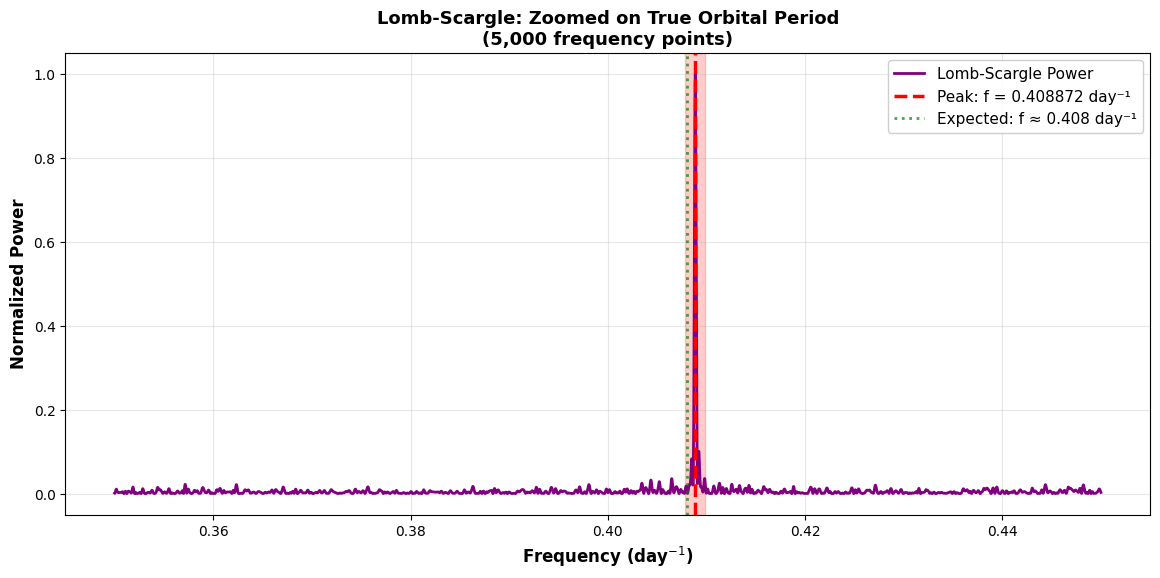

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
t, _, y, _, _, _ = np.loadtxt("pdmp.topo", unpack=True)
y = y - np.mean(y)
YY = np.sum(y**2)

# Frequencies around the TRUE period
#freq = np.linspace(0.35, 0.45, 2000)  # Zoomed tightly on 0.4 day^-1
freq = np.linspace(0.35, 0.45, 5000)
omega = 2.0 * np.pi * freq
power = np.zeros_like(freq)

print("Scanning around f ~ 0.4 day^-1 (P ~ 2.5 days)...")

for i, w in enumerate(omega):
    sum_sin = np.sum(np.sin(2*w*t))
    sum_cos = np.sum(np.cos(2*w*t))
    tau = np.arctan2(sum_sin, sum_cos) / (2*w)
    
    wt = w * (t - tau)
    C = np.sum(y * np.cos(wt))
    S = np.sum(y * np.sin(wt))
    CC = np.sum(np.cos(wt)**2)
    SS = np.sum(np.sin(wt)**2)
    
    power[i] = (1/YY) * (C**2/CC + S**2/SS)
        # ADD THIS to track progress:
    if (i + 1) % 1000 == 0:
        print(f"  Processed {i+1:,} / {len(freq):,} frequencies")

# Find peak in this specific window
idx = np.argmax(power)
f_peak = freq[idx]
P_peak = 1.0 / f_peak
# AFTER finding peak:
true_freq = 0.408  # From full periodogram
true_period = 1.0 / true_freq
print(f"Expected frequency: ~{true_freq:.3f} day⁻¹")
print(f"Expected period:    ~{true_period:.4f} days")
print(f"Deviation:          {abs(f_peak - true_freq):.6f} day⁻¹")


print("\n" + "="*50)
print("CORRECTED PEAK DETECTION")
print("="*50)
print(f"Peak Frequency: {f_peak:.4f} day⁻¹")
print(f"Orbital Period: {P_peak:.4f} days")
print(f"Power:          {power[idx]:.4f}")
print("="*50)

# IMPROVED PLOT:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(freq, power, color='purple', linewidth=2, label='Lomb-Scargle Power')

# Mark the peak
ax.axvline(f_peak, color='r', linestyle='--', linewidth=2.5, 
           label=f'Peak: f = {f_peak:.6f} day⁻¹')

# Mark expected value
ax.axvline(0.408, color='g', linestyle=':', linewidth=2, 
           label=f'Expected: f ≈ 0.408 day⁻¹', alpha=0.7)

# Shade peak region
ax.axvspan(f_peak - 0.001, f_peak + 0.001, alpha=0.2, color='red')

ax.set_xlabel("Frequency (day$^{-1}$)", fontsize=12, fontweight='bold')
ax.set_ylabel("Normalized Power", fontsize=12, fontweight='bold')
ax.set_title("Lomb-Scargle: Zoomed on True Orbital Period\n(5,000 frequency points)", 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3)
